> [A practical guide to asset weighting, Sharpe ratios, and performance evaluation](https://medium.com/@kyle-t-jones/portfolio-management-in-quant-finance-e7625cc3fbe9)

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Set matplotlib style
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False
})

In [2]:
# Generate synthetic asset return data
def generate_asset_returns(n_assets=3, n_periods=1000, seed=42):
    np.random.seed(seed)
    mean_returns = np.random.uniform(0.05, 0.15, n_assets)
    cov_matrix = np.random.uniform(0.001, 0.02, size=(n_assets, n_assets))
    cov_matrix = 0.5 * (cov_matrix + cov_matrix.T)  # Symmetric
    np.fill_diagonal(cov_matrix, np.random.uniform(0.01, 0.03, n_assets))
    returns = np.random.multivariate_normal(mean_returns, cov_matrix, size=n_periods)
    return returns, mean_returns, cov_matrix

# Compute portfolio return and risk
def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol

# Generate efficient frontier
def efficient_frontier(mean_returns, cov_matrix, n_portfolios=1000):
    n_assets = len(mean_returns)
    results = np.zeros((n_portfolios, 3))
    weights_record = []
    for i in range(n_portfolios):
        weights = np.random.dirichlet(np.ones(n_assets))
        ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
        sharpe = ret / vol
        results[i, 0], results[i, 1], results[i, 2] = ret, vol, sharpe
        weights_record.append(weights)
    return results, weights_record

# Calculate alpha and beta
def calculate_alpha_beta(asset_returns, market_returns, risk_free=0.0):
    excess_asset = asset_returns - risk_free
    excess_market = market_returns - risk_free
    cov = np.cov(excess_asset, excess_market)
    beta = cov[0, 1] / cov[1, 1]
    alpha = np.mean(excess_asset) - beta * np.mean(excess_market)
    return alpha, beta

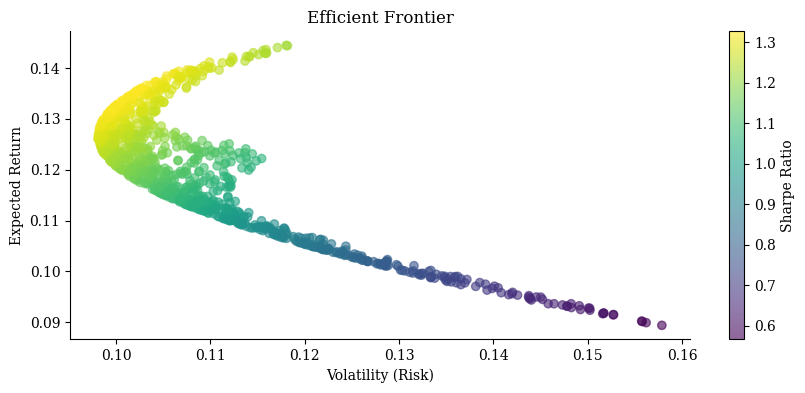

In [3]:
# Main simulation
returns, mean_returns, cov_matrix = generate_asset_returns()
results, _ = efficient_frontier(mean_returns, cov_matrix)

# Plot efficient frontier
plt.figure(figsize=(10, 4))
plt.scatter(results[:, 1], results[:, 0], c=results[:, 2], cmap='viridis', alpha=0.6)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
if "google.colab" not in sys.modules:
  plt.savefig("efficient_frontier.png")
plt.show()

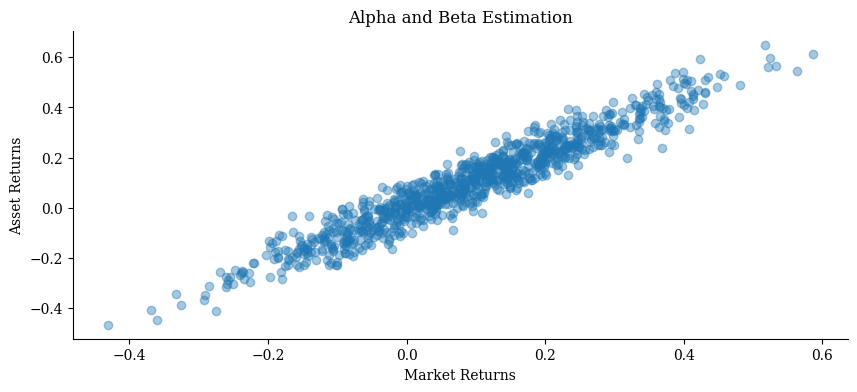

In [4]:
# Simulate alpha and beta for one asset
market_returns = np.random.normal(0.1, 0.15, size=1000)
asset_returns = 1.1 * market_returns + np.random.normal(0, 0.05, size=1000)
alpha, beta = calculate_alpha_beta(asset_returns, market_returns)

# Plot asset vs market returns
plt.figure(figsize=(10, 4))
plt.scatter(market_returns, asset_returns, alpha=0.4, label=f"Alpha: {alpha:.4f}, Beta: {beta:.2f}")
plt.xlabel("Market Returns")
plt.ylabel("Asset Returns")
plt.title("Alpha and Beta Estimation")
if "google.colab" not in sys.modules:
  plt.savefig("alpha_beta.png")
plt.show()